# 08. Normal-anchor drift: measuring forgetting and testing a consolidation repair

**Direction supported:** *"Don't Forget Normal"* — the primary paper core of `docs/neurips-brain-body.md`
(Direction A / D5). This is the only new notebook that **retrains** the model; everything it measures
comes from the repo's own 5-stage curriculum machinery, extended with one new loss term.

## Why this experiment exists

The canonical run recorded a clean, quantified forgetting curve. The cosine between the pooled normal
representation and its **Stage-0 reference ("normal anchor")** fell from **0.954** (after Stage 1) to
**0.594** (after Stage 4):

| Stage | Added condition | Normal-anchor cosine (canonical run) |
|---|---|---|
| 1 | Parkinson's | 0.954 |
| 2 | stroke | 0.839 |
| 3 | myopathic | 0.707 |
| 4 | cerebral palsy | **0.594** |

Balanced replay kept earlier groups in the optimizer stream, but it did **not** prevent the model from
drifting away from its own normal reference. For a *body-representation world model*, forgetting what
"normal" looks like is a deployment hazard, not a benchmark nuisance — and it is a textbook
**continual-learning failure mode** (a workshop topic: *continual learning in biosignal contexts*).

This notebook runs three steps:

1. **Reproduce the drift** from the five frozen checkpoints (seconds) — a KILL gate: if the canonical
   curve does not reproduce, the paper premise fails.
2. **Attribute the drift** with a matched ablation: retrain Stage 1 (Parkinson's) twice from the frozen
   Stage-0 checkpoint, once with the label-aware group margin (0.25) and once with it zeroed. If drift
   tracks the group term, supervised separation — not the new data per se — is pulling the anchor.
3. **Repair the drift** with *AnchorGuard*: one full 600-epoch curriculum retrain where Stages 1–4 add a
   label-free anchor-distillation term that pulls the running normal pooled vector back toward the
   frozen Stage-0 reference. Pre-registered success: Stage-4 anchor cosine ≥ 0.85 with no collapse and
   no more than a 0.05 macro-F1 loss on source-grouped probes.

**Cost:** the full AnchorGuard retrain is ~20–25 min on this machine (the canonical run's own
timestamps show 2–7 min per stage); the two margin-ablation runs are ~3–4 min each.

## Claim discipline (unchanged)

* Source video is the independent unit; probes below are grouped by `video_id`.
* Even retrained fold-locally, this corpus cannot support *clinical generalization claims*: one
  canonical normal video, two Parkinson's videos, two CP videos. Every number here is an in-corpus
  mechanistic result.
* Folder labels are dataset annotations, not diagnoses.

**Research use only.** Nothing here diagnoses a person or validates a clinical device.


In [1]:
from pathlib import Path
import os
import sys
import math

# --- Robust project-layout resolution -------------------------------------
NOTEBOOK_DIR = Path.cwd().resolve()
if not (NOTEBOOK_DIR / "work").exists() and os.getenv("ALEXPOSE_ROOT"):
    NOTEBOOK_DIR = (
        Path(os.environ["ALEXPOSE_ROOT"]).expanduser().resolve()
        / "experiments" / "sjepa" / "gavd5-drift"
    )
if not (NOTEBOOK_DIR / "work").exists():
    raise FileNotFoundError(
        f"Cannot locate the gavd5-drift project folder from {NOTEBOOK_DIR}. "
        "Run this notebook from experiments/sjepa/gavd5-drift or set ALEXPOSE_ROOT."
    )

MODE = os.environ.setdefault("GAVD_MODE", "real").strip().lower()
if MODE not in {"smoke", "real"}:
    raise ValueError("GAVD_MODE must be smoke or real")

CACHE_DIR = Path(
    os.environ.setdefault("GAVD_CACHE_DIR", str(NOTEBOOK_DIR / "cache"))
).expanduser()
ARTIFACT_ROOT = Path(
    os.environ.setdefault(
        "GAVD_ARTIFACT_DIR", str(NOTEBOOK_DIR / "work" / "artifacts")
    )
).expanduser()
ARTIFACT_DIR = ARTIFACT_ROOT / MODE
POSE_DIR = ARTIFACT_DIR / "poses"
AUGMENTED_POSE_DIR = ARTIFACT_DIR / "poses_augmented"
AUGMENTED_REPORT = ARTIFACT_DIR / "augmented_pose_extraction_report.csv"

INCLUDE_AUGMENTED_NORMAL = os.environ.setdefault(
    "SJEPA_INCLUDE_AUGMENTED_NORMAL", "0"
).strip().lower() in {"1", "true", "yes", "on"}

for folder in [CACHE_DIR, ARTIFACT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(CACHE_DIR / "matplotlib"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd

print(f"mode: {MODE}")
print(f"artifacts: {ARTIFACT_DIR}")
print("augmentation-normal cohort: "
      + ("ENABLED (additive)" if INCLUDE_AUGMENTED_NORMAL else "disabled"))


mode: real
artifacts: /Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/work/artifacts/real
augmentation-normal cohort: disabled


In [2]:
BLAZEPOSE_33 = [
    "NOSE", "LEFT_EYE_INNER", "LEFT_EYE", "LEFT_EYE_OUTER",
    "RIGHT_EYE_INNER", "RIGHT_EYE", "RIGHT_EYE_OUTER", "LEFT_EAR",
    "RIGHT_EAR", "MOUTH_LEFT", "MOUTH_RIGHT", "LEFT_SHOULDER",
    "RIGHT_SHOULDER", "LEFT_ELBOW", "RIGHT_ELBOW", "LEFT_WRIST",
    "RIGHT_WRIST", "LEFT_PINKY", "RIGHT_PINKY", "LEFT_INDEX",
    "RIGHT_INDEX", "LEFT_THUMB", "RIGHT_THUMB", "LEFT_HIP",
    "RIGHT_HIP", "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE",
    "RIGHT_ANKLE", "LEFT_HEEL", "RIGHT_HEEL", "LEFT_FOOT_INDEX",
    "RIGHT_FOOT_INDEX",
]
MASK_KEYPOINTS = [11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
CONDITIONS = ["normal", "parkinsons", "stroke", "myopathic", "cerebralpalsy"]
CURRICULUM = [
    {"stage": 0, "name": "normal_only", "add": "normal",
     "conditions": ["normal"]},
    {"stage": 1, "name": "add_parkinsons", "add": "parkinsons",
     "conditions": ["normal", "parkinsons"]},
    {"stage": 2, "name": "add_stroke", "add": "stroke",
     "conditions": ["normal", "parkinsons", "stroke"]},
    {"stage": 3, "name": "add_myopathic", "add": "myopathic",
     "conditions": ["normal", "parkinsons", "stroke", "myopathic"]},
    {"stage": 4, "name": "add_cerebralpalsy", "add": "cerebralpalsy",
     "conditions": ["normal", "parkinsons", "stroke", "myopathic",
                    "cerebralpalsy"]},
]
EXPECTED_SEQUENCE_COUNTS = {
    "normal": 284, "parkinsons": 42, "stroke": 75,
    "myopathic": 183, "cerebralpalsy": 58,
}


In [3]:
import copy
import torch
from torch import nn


class SkeletonPatchEncoder(nn.Module):
    def __init__(
        self,
        frames=64,
        joints=33,
        coordinate_dim=3,
        segment_length=4,
        embed_dim=64,
        depth=2,
        heads=4,
        dropout=0.0,
    ):
        super().__init__()
        if frames % segment_length:
            raise ValueError("frames must be divisible by segment_length")
        self.frames = frames
        self.joints = joints
        self.coordinate_dim = coordinate_dim
        self.segment_length = segment_length
        self.segments = frames // segment_length
        self.embed_dim = embed_dim
        self.patch_embed = nn.Linear(segment_length * coordinate_dim, embed_dim)
        self.time_pos = nn.Parameter(torch.randn(self.segments, embed_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(joints, embed_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)

    def patchify(self, x):
        batch, frames, joints, channels = x.shape
        expected = (self.frames, self.joints, self.coordinate_dim)
        if (frames, joints, channels) != expected:
            raise ValueError(f"Expected [B, {expected}], received {x.shape}")
        patches = x.reshape(
            batch, self.segments, self.segment_length, joints, channels
        )
        patches = patches.permute(0, 1, 3, 2, 4).contiguous()
        return patches.flatten(3)

    def positioned_tokens(self, x):
        tokens = self.patch_embed(self.patchify(x))
        return (
            tokens
            + self.time_pos[None, :, None, :]
            + self.joint_pos[None, None, :, :]
        )

    def forward(self, x, keep_mask=None):
        tokens = self.positioned_tokens(x)
        batch = len(tokens)
        flat = tokens.reshape(batch, self.segments * self.joints, self.embed_dim)
        if keep_mask is not None:
            keep_mask = keep_mask.reshape(batch, -1)
            kept_per_sample = keep_mask.sum(dim=1)
            if not torch.equal(
                kept_per_sample, kept_per_sample[:1].expand_as(kept_per_sample)
            ):
                raise ValueError("Each sample must keep the same number of tokens")
            flat = flat[keep_mask].reshape(
                batch, int(kept_per_sample[0]), self.embed_dim
            )
        return self.norm(self.blocks(flat))


class SkeletonPredictor(nn.Module):
    def __init__(
        self,
        segments,
        joints,
        encoder_dim=64,
        predictor_dim=64,
        depth=2,
        heads=4,
        dropout=0.0,
    ):
        super().__init__()
        self.segments = segments
        self.joints = joints
        self.encoder_to_predictor = nn.Linear(encoder_dim, predictor_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, predictor_dim))
        nn.init.normal_(self.mask_token, std=0.02)
        self.time_pos = nn.Parameter(torch.randn(segments, predictor_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(joints, predictor_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=predictor_dim,
            nhead=heads,
            dim_feedforward=predictor_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(predictor_dim)
        self.output = nn.Linear(predictor_dim, encoder_dim)

    def forward(self, visible_features, target_mask):
        batch = len(visible_features)
        target_mask = target_mask.reshape(batch, self.segments * self.joints)
        visible_mask = ~target_mask
        visible = self.encoder_to_predictor(visible_features)
        full = self.mask_token.expand(
            batch, self.segments * self.joints, -1
        ).clone()
        full[visible_mask] = visible.reshape(-1, visible.shape[-1])
        positions = (
            self.time_pos[:, None, :] + self.joint_pos[None, :, :]
        ).reshape(1, self.segments * self.joints, -1)
        full = full + positions
        predicted = self.output(self.norm(self.blocks(full)))
        return predicted[target_mask].reshape(batch, -1, predicted.shape[-1])


class SJEPAGait(nn.Module):
    def __init__(
        self,
        frames=64,
        joints=33,
        coordinate_dim=3,
        segment_length=4,
        embed_dim=64,
        encoder_depth=2,
        predictor_depth=2,
        heads=4,
    ):
        super().__init__()
        self.view_encoder = SkeletonPatchEncoder(
            frames, joints, coordinate_dim, segment_length,
            embed_dim, encoder_depth, heads,
        )
        self.target_encoder = copy.deepcopy(self.view_encoder)
        for parameter in self.target_encoder.parameters():
            parameter.requires_grad_(False)
        self.predictor = SkeletonPredictor(
            self.view_encoder.segments,
            joints,
            embed_dim,
            embed_dim,
            predictor_depth,
            heads,
        )
        self.register_buffer("target_center", torch.zeros(embed_dim))

    def forward(self, view, target, target_mask):
        visible_features = self.view_encoder(view, keep_mask=~target_mask)
        predicted = self.predictor(visible_features, target_mask)
        with torch.no_grad():
            all_targets = self.target_encoder(target)
            flat_mask = target_mask.reshape(len(target), -1)
            selected = all_targets[flat_mask].reshape(
                len(target), -1, all_targets.shape[-1]
            )
        return predicted, selected

    @torch.no_grad()
    def update_target(self, momentum):
        for target_parameter, view_parameter in zip(
            self.target_encoder.parameters(), self.view_encoder.parameters()
        ):
            target_parameter.mul_(momentum).add_(
                view_parameter, alpha=1.0 - momentum
            )

    @torch.no_grad()
    def update_center(self, targets, beta=0.9):
        batch_center = targets.mean(dim=(0, 1))
        self.target_center.mul_(beta).add_(batch_center, alpha=1.0 - beta)


def sjepa_cross_entropy(
    predicted,
    targets,
    center,
    predictor_temperature=0.10,
    target_temperature=0.06,
):
    target_prob = torch.softmax(
        (targets - center[None, None, :]) / target_temperature,
        dim=-1,
    ).detach()
    prediction_log_prob = torch.log_softmax(
        predicted / predictor_temperature,
        dim=-1,
    )
    return -(target_prob * prediction_log_prob).sum(dim=-1).mean()


def cosine_ema(step, total_steps, start=0.996, end=1.0):
    progress = min(max(step / max(total_steps - 1, 1), 0.0), 1.0)
    return end - (end - start) * (math.cos(math.pi * progress) + 1.0) / 2.0


def geometric_view(x, max_degrees=8.0, translate=0.03, flip_probability=0.0):
    view = x.clone()
    present = view.abs().sum(dim=-1) > 1e-8
    batch = len(view)
    angles = (
        torch.rand(batch, device=x.device) * 2.0 - 1.0
    ) * math.radians(max_degrees)
    cosine, sine = torch.cos(angles), torch.sin(angles)
    original_x = view[..., 0].clone()
    original_z = view[..., 2].clone()
    rotated_x = cosine[:, None, None] * original_x - sine[:, None, None] * original_z
    rotated_z = sine[:, None, None] * original_x + cosine[:, None, None] * original_z
    view[..., 0] = torch.where(present, rotated_x, view[..., 0])
    view[..., 2] = torch.where(present, rotated_z, view[..., 2])
    translation = (
        (torch.rand(batch, device=x.device) * 2.0 - 1.0) * translate
    )[:, None, None, None]
    view[..., :3] = view[..., :3] + translation
    if flip_probability > 0.0:
        raise NotImplementedError(
            "flip_probability must stay 0.0 in this notebook (laterality safety)"
        )
    return view


In [4]:
def interpolate_low_visibility(sequence, threshold=0.45, max_gap=4):
    # Fill only short internal gaps and preserve the original validity mask.
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
        raise ValueError(f"Expected [T, 33, 4], received {sequence.shape}")
    visibility = np.nan_to_num(sequence[..., 3], nan=0.0)
    finite = np.isfinite(sequence[..., :3]).all(axis=-1)
    valid = (visibility >= threshold) & finite
    filled = valid.copy()
    for joint in range(33):
        observed = np.flatnonzero(valid[:, joint])
        for left, right in zip(observed[:-1], observed[1:]):
            gap = int(right - left - 1)
            if not 0 < gap <= max_gap:
                continue
            fraction = (
                np.arange(1, gap + 1, dtype=np.float32) / (gap + 1)
            )[:, None]
            sequence[left + 1:right, joint, :3] = (
                sequence[left, joint, :3][None, :] * (1.0 - fraction)
                + sequence[right, joint, :3][None, :] * fraction
            )
            filled[left + 1:right, joint] = True
        sequence[~filled[:, joint], joint, :3] = np.nan
    sequence[..., 3] = visibility
    return sequence, valid


def center_and_scale(sequence, eps=1e-6):
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    xyz = sequence[..., :3]
    left_hip, right_hip = xyz[:, 23], xyz[:, 24]
    left_ok = np.isfinite(left_hip).all(axis=1)
    right_ok = np.isfinite(right_hip).all(axis=1)
    pelvis = np.full((len(xyz), 3), np.nan, dtype=np.float32)
    pelvis[left_ok & right_ok] = 0.5 * (
        left_hip[left_ok & right_ok] + right_hip[left_ok & right_ok]
    )
    pelvis[left_ok & ~right_ok] = left_hip[left_ok & ~right_ok]
    pelvis[right_ok & ~left_ok] = right_hip[right_ok & ~left_ok]
    pelvis_ok = np.isfinite(pelvis).all(axis=1)
    fallback = np.median(pelvis[pelvis_ok], axis=0) if pelvis_ok.any() else np.zeros(3)
    pelvis[~np.isfinite(pelvis).all(axis=1)] = fallback
    xyz = xyz - pelvis[:, None, :]
    shoulder_width = np.linalg.norm(xyz[:, 11, :2] - xyz[:, 12, :2], axis=-1)
    hip_width = np.linalg.norm(xyz[:, 23, :2] - xyz[:, 24, :2], axis=-1)
    body_scale = np.nanmedian(np.maximum(shoulder_width, hip_width))
    if not np.isfinite(body_scale) or body_scale < eps:
        body_scale = 1.0
    sequence[..., :3] = np.nan_to_num(
        xyz / body_scale, nan=0.0, posinf=0.0, neginf=0.0
    )
    return np.nan_to_num(sequence, nan=0.0, posinf=0.0, neginf=0.0)


def temporal_resize(array, frames):
    array = np.asarray(array)
    if len(array) == frames:
        return array.copy()
    if len(array) < 2:
        return np.repeat(array, frames, axis=0)
    old_t = np.linspace(0.0, 1.0, len(array))
    new_t = np.linspace(0.0, 1.0, frames)
    flat = array.reshape(len(array), -1)
    resized = np.stack(
        [np.interp(new_t, old_t, flat[:, i]) for i in range(flat.shape[1])],
        axis=1,
    )
    return resized.reshape(frames, *array.shape[1:]).astype(array.dtype)


def prepare_sequence(sequence, frames=64, visibility_threshold=0.45, max_gap=4):
    cleaned, valid = interpolate_low_visibility(
        sequence, visibility_threshold, max_gap=max_gap
    )
    cleaned = center_and_scale(cleaned)
    cleaned = temporal_resize(cleaned, frames)
    valid = temporal_resize(valid.astype(np.float32), frames) >= 0.5
    return cleaned[..., :3].astype(np.float32), valid.astype(bool)


In [5]:
def pose_records_from_cache(pose_dir=POSE_DIR, conditions=CONDITIONS):
    records = []
    for condition in conditions:
        folder = Path(pose_dir) / condition
        for path in sorted(folder.glob("*.npz")):
            data = np.load(path, allow_pickle=False)
            required = {
                "sequence", "sequence_id", "video_id", "condition",
                "frame_numbers", "crop_bounds", "fps", "source_csv",
                "source_video", "pose_model", "pose_model_sha256",
                "extraction_version",
            }
            missing = required.difference(data.files)
            if missing:
                raise ValueError(
                    f"Stale pose cache {path} is missing {sorted(missing)}. "
                    "Re-extract it with notebook 02."
                )
            sequence = data["sequence"].astype(np.float32)
            if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
                raise ValueError(f"Bad pose shape in {path}: {sequence.shape}")
            stored = str(data["condition"].item())
            if stored != condition:
                raise ValueError(
                    f"Pose condition {stored} does not match folder {condition}"
                )
            records.append({
                "condition": condition,
                "sequence_id": str(data["sequence_id"].item()),
                "video_id": str(data["video_id"].item()),
                "source_video": str(data["source_video"].item()),
                "fps": float(data["fps"].item()),
                "sequence": sequence,
                "path": str(path),
            })
    return records


def load_records_for_mode(conditions=CONDITIONS, frames=64):
    if MODE == "smoke":
        raise NotImplementedError("This notebook is designed for the real corpus.")
    records = pose_records_from_cache(conditions=conditions)
    counts = pd.Series([r["condition"] for r in records]).value_counts()
    missing = [c for c in conditions if counts.get(c, 0) == 0]
    if missing:
        raise FileNotFoundError(
            f"Real mode requires cached pose sequences for {missing}. Run notebook 02 first."
        )
    print(f"Real pose corpus: {len(records)} sequences")
    return records


def augmented_normal_records(pose_dir=AUGMENTED_POSE_DIR):
    if not INCLUDE_AUGMENTED_NORMAL or MODE != "real":
        return []
    folder = Path(pose_dir) / "normal"
    if not folder.exists():
        raise FileNotFoundError(
            f"SJEPA_INCLUDE_AUGMENTED_NORMAL is set but {folder} is missing."
        )
    report = pd.read_csv(AUGMENTED_REPORT)
    candidates = report[
        ~report["status"].astype(str).str.startswith("error")
    ].copy()
    candidates["accepted"] = (
        pd.to_numeric(candidates["neuro_observed"], errors="coerce") >= 0.45
    )
    selected_ids = set(
        candidates.loc[candidates["accepted"], "sequence_id"].astype(str)
    )
    available = {path.stem: path for path in folder.glob("*.npz")}
    missing_selected = sorted(selected_ids.difference(available))
    if missing_selected:
        raise FileNotFoundError(
            f"Accepted augmented pose files are missing: {missing_selected}"
        )
    records = []
    for sequence_id in sorted(selected_ids):
        path = available[sequence_id]
        data = np.load(path, allow_pickle=False)
        records.append({
            "condition": "normal",
            "sequence_id": str(data["sequence_id"].item()),
            "video_id": str(data["video_id"].item()),
            "source_video": str(data["source_video"].item()),
            "fps": float(data["fps"].item()),
            "cohort": "augmented_normal",
            "sequence": data["sequence"].astype(np.float32),
            "path": str(path),
        })
    return records


In [6]:
from torch.nn import functional as F


def uniform_neurologic_mask(valid_patch, mask_fraction=0.60, seed=None):
    # Sample eligible joint-time tokens uniformly, WITHOUT motion scores.
    valid_patch = np.asarray(valid_patch, dtype=bool)
    if valid_patch.ndim != 3 or valid_patch.shape[2] != 33:
        raise ValueError(f"Expected [B, S, 33], received {valid_patch.shape}")
    if not 0.0 < mask_fraction < 1.0:
        raise ValueError("mask_fraction must be between 0 and 1")
    rng = np.random.default_rng(seed)
    eligible_joint = np.zeros(33, dtype=bool)
    eligible_joint[MASK_KEYPOINTS] = True
    eligible = valid_patch & eligible_joint[None, None, :]
    counts = eligible.reshape(len(eligible), -1).sum(axis=1)
    if np.any(counts < 2):
        raise ValueError("Each sample needs at least two valid eligible tokens")
    n_mask = max(1, int(np.floor(counts.min() * mask_fraction)))
    n_mask = min(n_mask, int(counts.min()) - 1)
    mask = np.zeros_like(eligible)
    for batch_index in range(len(mask)):
        candidates = np.flatnonzero(eligible[batch_index].reshape(-1))
        chosen = rng.choice(candidates, size=n_mask, replace=False)
        mask[batch_index].reshape(-1)[chosen] = True
    forbidden = sorted(set(range(33)).difference(MASK_KEYPOINTS))
    assert not mask[:, :, forbidden].any()
    assert mask.reshape(len(mask), -1).any(axis=1).all()
    assert (~mask).reshape(len(mask), -1).any(axis=1).all()
    return mask


def mask_audit(mask, valid_patch):
    mask = np.asarray(mask, dtype=bool)
    valid_patch = np.asarray(valid_patch, dtype=bool)
    eligible_joint = np.zeros(33, dtype=bool)
    eligible_joint[MASK_KEYPOINTS] = True
    eligible = valid_patch & eligible_joint[None, None, :]
    masked_counts = mask.reshape(len(mask), -1).sum(axis=1)
    eligible_counts = eligible.reshape(len(mask), -1).sum(axis=1)
    per_sample_ratio = masked_counts / eligible_counts
    return {
        "global_fraction": float(mask.mean()),
        "eligible_mask_fraction_mean": float(per_sample_ratio.mean()),
        "forbidden_count": int(
            mask[:, :, sorted(set(range(33)) - set(MASK_KEYPOINTS))].sum()
        ),
    }


class VICRegProjector(nn.Module):
    def __init__(self, dimension):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dimension, dimension),
            nn.GELU(),
            nn.Linear(dimension, dimension),
        )

    def forward(self, x):
        return self.net(x)


def authorized_pool(tokens, valid_patch):
    batch, segments, _, dimension = tokens.shape
    selected = tokens[:, :, MASK_KEYPOINTS].reshape(batch, -1, dimension)
    weights = valid_patch[:, :, MASK_KEYPOINTS].reshape(batch, -1).to(tokens.dtype)
    denominator = weights.sum(dim=1, keepdim=True).clamp_min(1.0)
    return (selected * weights.unsqueeze(-1)).sum(dim=1) / denominator


def off_diagonal(matrix):
    n, m = matrix.shape
    if n != m:
        raise ValueError("Covariance matrix must be square")
    return matrix.flatten()[:-1].view(n - 1, n + 1)[:, 1:].flatten()


def vicreg_terms(first, second, gamma=1.0, eps=1e-4):
    invariance = F.mse_loss(first, second)
    first_std = torch.sqrt(first.var(dim=0, unbiased=False) + eps)
    second_std = torch.sqrt(second.var(dim=0, unbiased=False) + eps)
    variance = 0.5 * (
        F.relu(gamma - first_std).mean()
        + F.relu(gamma - second_std).mean()
    )
    first_centered = first - first.mean(dim=0)
    second_centered = second - second.mean(dim=0)
    denominator = max(len(first) - 1, 1)
    first_cov = first_centered.T @ first_centered / denominator
    second_cov = second_centered.T @ second_centered / denominator
    covariance = (
        off_diagonal(first_cov).square().sum()
        + off_diagonal(second_cov).square().sum()
    ) / (2.0 * first.shape[1])
    weighted = 25.0 * invariance + 25.0 * variance + covariance
    return weighted, invariance, variance, covariance


def condition_group_terms(representations, condition_ids, margin=1.0):
    unique = torch.unique(condition_ids)
    zero = representations.sum() * 0.0
    if len(unique) < 2:
        return zero, zero, torch.tensor(
            float("nan"), device=representations.device
        )
    normalized = F.normalize(representations, dim=1)
    centroids = torch.stack([
        F.normalize(normalized[condition_ids == value].mean(dim=0), dim=0)
        for value in unique
    ])
    compactness = torch.stack([
        (normalized[condition_ids == value] - centroids[index])
        .square().sum(dim=1).mean()
        for index, value in enumerate(unique)
    ]).mean()
    pairwise = (
        (centroids[:, None] - centroids[None, :]).square().sum(dim=-1)
        .clamp_min(1e-12).sqrt()
    )
    upper = torch.triu(torch.ones_like(pairwise, dtype=torch.bool), diagonal=1)
    distances = pairwise[upper]
    separation = F.relu(margin - distances).square().mean()
    return compactness, separation, distances.min()


def balanced_epoch_batches(data_by_condition, active_conditions, per_condition, rng):
    lengths = {
        condition: len(data_by_condition[condition]["xyz"])
        for condition in active_conditions
    }
    if min(lengths.values()) < 1:
        raise ValueError(f"Empty curriculum condition: {lengths}")
    steps = max(1, int(np.ceil(max(lengths.values()) / per_condition)))
    required = steps * per_condition
    orders = {}
    for condition in active_conditions:
        pieces = []
        while sum(len(piece) for piece in pieces) < required:
            pieces.append(rng.permutation(lengths[condition]))
        orders[condition] = np.concatenate(pieces)[:required]
    for step in range(steps):
        xyz_parts, valid_parts, label_parts = [], [], []
        for label, condition in enumerate(active_conditions):
            take = orders[condition][
                step * per_condition:(step + 1) * per_condition
            ]
            xyz_parts.append(data_by_condition[condition]["xyz"][take])
            valid_parts.append(data_by_condition[condition]["valid"][take])
            label_parts.extend([label] * per_condition)
        permutation = rng.permutation(len(label_parts))
        yield (
            np.concatenate(xyz_parts)[permutation],
            np.concatenate(valid_parts)[permutation],
            np.asarray(label_parts, dtype=np.int64)[permutation],
        )


@torch.no_grad()
def target_authorized_embeddings(model, arrays, validity, batch_size=16):
    model.target_encoder.eval()
    vectors = []
    segments = FRAMES // SEGMENT_LENGTH
    for start in range(0, len(arrays), batch_size):
        batch = torch.tensor(
            arrays[start:start + batch_size], dtype=torch.float32, device=device
        )
        valid = torch.tensor(
            validity[start:start + batch_size], dtype=torch.bool, device=device
        )
        valid_patch = valid.reshape(
            len(batch), segments, SEGMENT_LENGTH, 33
        ).all(dim=2)
        tokens = model.target_encoder(batch).reshape(
            len(batch), segments, 33, EMBED_DIM
        )
        vectors.append(authorized_pool(tokens, valid_patch))
    return torch.cat(vectors)


def representation_diagnostics(
    model, data_by_condition, active_conditions, normal_reference=None
):
    arrays = np.concatenate(
        [data_by_condition[c]["xyz"] for c in active_conditions]
    )
    validity = np.concatenate(
        [data_by_condition[c]["valid"] for c in active_conditions]
    )
    labels = np.concatenate([
        np.full(len(data_by_condition[c]["xyz"]), index, dtype=np.int64)
        for index, c in enumerate(active_conditions)
    ])
    vectors = target_authorized_embeddings(model, arrays, validity)
    feature_std = float(vectors.std(dim=0, unbiased=False).mean())
    unit = F.normalize(vectors, dim=1)
    cosine = unit @ unit.T
    eye = torch.eye(len(unit), dtype=torch.bool)
    mean_pair_cosine = float(cosine[~eye].mean()) if len(unit) > 1 else float("nan")
    centroids = torch.stack([
        F.normalize(unit[torch.tensor(labels) == value].mean(dim=0), dim=0)
        for value in range(len(active_conditions))
    ])
    pairwise = (
        (centroids[:, None] - centroids[None, :]).square().sum(dim=-1)
        .clamp_min(1e-12).sqrt()
    )
    upper = torch.triu(torch.ones_like(pairwise, dtype=torch.bool), diagonal=1)
    distances = pairwise[upper]
    minimum_centroid_distance = (
        float(distances.min()) if len(distances) else float("nan")
    )
    mean_centroid_distance = (
        float(distances.mean()) if len(distances) else float("nan")
    )
    normal_anchor_cosine = float("nan")
    if normal_reference is not None:
        current_normal = vectors[:len(normal_reference)]
        normal_anchor_cosine = float(
            F.cosine_similarity(current_normal, normal_reference, dim=1).mean()
        )
    return {
        "feature_std": feature_std,
        "mean_pair_cosine": mean_pair_cosine,
        "minimum_centroid_distance": minimum_centroid_distance,
        "mean_centroid_distance": mean_centroid_distance,
        "normal_anchor_cosine": normal_anchor_cosine,
    }


def compute_anchor_reference(model, xyz, validity):
    # Label-free Stage-0 anchor: unit-normalized mean of the VIEW encoder's
    # authorized pooled vectors over the normal corpus. This lives in the same
    # space as the anchor-loss inputs (student side), avoiding EMA mismatch.
    segments = FRAMES // SEGMENT_LENGTH
    pooled = []
    with torch.no_grad():
        for start in range(0, len(xyz), 16):
            batch = torch.tensor(
                xyz[start:start + 16], dtype=torch.float32, device=device
            )
            valid = torch.tensor(
                validity[start:start + 16], dtype=torch.bool, device=device
            )
            valid_patch = valid.reshape(
                len(batch), segments, SEGMENT_LENGTH, 33
            ).all(dim=2)
            tokens = model.view_encoder(batch).reshape(
                len(batch), segments, 33, EMBED_DIM
            )
            pooled.append(authorized_pool(tokens, valid_patch))
    stacked = F.normalize(torch.cat(pooled), dim=1)
    return F.normalize(stacked.mean(dim=0), dim=0)


## Training loop (notebook-04-faithful, plus the anchor term)

`train_stage` below is the exact loop of notebook 04 with one extension: when `anchor_c0` and
`anchor_weight` are set, the total loss adds

$$L_{anchor} = \\lambda_{anchor} \\cdot (1 - \\text{mean}_n \\cos(z_n, c_0)),$$

where $z_n$ are the unprojected authorized pooled student vectors of the **normal** rows in the batch
and $c_0$ is the frozen Stage-0 anchor. This is **label-free** (it only selects rows already labeled
"normal" in the manifest; it never reads the pathology labels) and it acts in representation space,
the same space where the drift is measured.


In [7]:
def train_stage(
    stage,
    epochs,
    learning_rate,
    normal_reference=None,
    anchor_c0=None,
    anchor_weight=0.0,
):
    # Continue the same model; only optimizer/schedule state restarts.
    active = stage["conditions"]
    trainable = [
        *[p for p in model.view_encoder.parameters() if p.requires_grad],
        *[p for p in model.predictor.parameters() if p.requires_grad],
        *list(vicreg_projector.parameters()),
    ]
    optimizer = torch.optim.AdamW(
        trainable, lr=learning_rate, betas=(0.9, 0.95), weight_decay=0.05
    )
    steps_per_epoch = max(
        1,
        int(np.ceil(
            max(len(condition_data[c]["xyz"]) for c in active)
            / SAMPLES_PER_CONDITION
        )),
    )
    total_steps = epochs * steps_per_epoch
    warmup_steps = max(1, min(steps_per_epoch, total_steps // 10))

    def lr_factor(step):
        if step < warmup_steps:
            return (step + 1) / warmup_steps
        progress = (step - warmup_steps) / max(
            total_steps - warmup_steps - 1, 1
        )
        return 0.5 + 0.5 * (1.0 + math.cos(math.pi * progress)) / 2.0

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_factor)
    rng = np.random.default_rng(42 + 1000 * stage["stage"])
    stage_rows = []
    global_step = 0
    for epoch in range(epochs):
        model.train()
        vicreg_projector.train()
        batch_rows = []
        for xyz_np, valid_np, labels_np in balanced_epoch_batches(
            condition_data, active, SAMPLES_PER_CONDITION, rng
        ):
            coordinates = torch.tensor(xyz_np, dtype=torch.float32, device=device)
            valid = torch.tensor(valid_np, dtype=torch.bool, device=device)
            labels_tensor = torch.tensor(labels_np, dtype=torch.long, device=device)
            segments = FRAMES // SEGMENT_LENGTH
            valid_patch = valid.reshape(
                len(valid), segments, SEGMENT_LENGTH, 33
            ).all(dim=2)
            eligible_counts = valid_patch[:, :, MASK_KEYPOINTS].reshape(
                len(valid), -1
            ).sum(dim=1)
            if int(eligible_counts.min()) < 2:
                raise ValueError(
                    "Every sampled sequence needs at least two valid authorized patches"
                )
            mask_np = uniform_neurologic_mask(
                valid_patch.cpu().numpy(), mask_fraction=MASK_FRACTION,
                seed=42 + 100000 * stage["stage"] + global_step,
            )
            mask_stats = mask_audit(mask_np, valid_patch.cpu().numpy())
            if mask_stats["forbidden_count"] != 0:
                raise AssertionError("A forbidden keypoint entered the target mask")
            target_mask = torch.tensor(mask_np, dtype=torch.bool, device=device)
            view_a = geometric_view(
                coordinates, max_degrees=8.0, translate=0.03,
                flip_probability=0.0
            )
            view_b = geometric_view(
                coordinates, max_degrees=8.0, translate=0.03,
                flip_probability=0.0
            )

            prediction, target = model(view_a, coordinates, target_mask)
            jepa_loss = sjepa_cross_entropy(
                prediction, target, model.target_center
            )

            tokens_a = model.view_encoder(view_a).reshape(
                len(view_a), segments, 33, EMBED_DIM
            )
            tokens_b = model.view_encoder(view_b).reshape(
                len(view_b), segments, 33, EMBED_DIM
            )
            pooled_a = authorized_pool(tokens_a, valid_patch)
            pooled_b = authorized_pool(tokens_b, valid_patch)
            projected_a = vicreg_projector(pooled_a)
            projected_b = vicreg_projector(pooled_b)
            vicreg_loss, invariance, variance, covariance = vicreg_terms(
                projected_a, projected_b
            )
            compactness, separation, batch_min_centroid = (
                condition_group_terms(pooled_a, labels_tensor, margin=GROUP_MARGIN)
            )
            group_loss = compactness + separation
            total_loss = (
                jepa_loss + VICREG_WEIGHT * vicreg_loss
                + GROUP_WEIGHT * group_loss
            )
            anchor_loss = total_loss * 0.0
            if anchor_weight > 0.0 and anchor_c0 is not None:
                normal_index = active.index("normal")
                normal_rows = labels_tensor == normal_index
                if int(normal_rows.sum()) > 0:
                    anchor_loss = (
                        1.0
                        - F.cosine_similarity(
                            pooled_a[normal_rows], anchor_c0[None, :], dim=-1
                        ).mean()
                    )
                    total_loss = total_loss + anchor_weight * anchor_loss
            if not torch.isfinite(total_loss):
                raise FloatingPointError(
                    f"Non-finite loss in {stage['name']} step {global_step}"
                )

            optimizer.zero_grad(set_to_none=True)
            total_loss.backward()
            assert all(
                parameter.grad is None
                for parameter in model.target_encoder.parameters()
            )
            torch.nn.utils.clip_grad_norm_(trainable, max_norm=1.0)
            optimizer.step()
            scheduler.step()
            momentum = cosine_ema(global_step, total_steps, start=EMA_START, end=1.0)
            model.update_target(momentum)
            model.update_center(target, beta=0.9)

            batch_rows.append({
                "total_loss": float(total_loss.detach().cpu()),
                "jepa_loss": float(jepa_loss.detach().cpu()),
                "vicreg_loss": float(vicreg_loss.detach().cpu()),
                "vicreg_invariance": float(invariance.detach().cpu()),
                "vicreg_variance": float(variance.detach().cpu()),
                "vicreg_covariance": float(covariance.detach().cpu()),
                "group_compactness": float(compactness.detach().cpu()),
                "group_separation": float(separation.detach().cpu()),
                "batch_min_centroid_distance": float(
                    batch_min_centroid.detach().cpu()
                ),
                "anchor_loss": float(anchor_loss.detach().cpu()),
                "global_mask_fraction": mask_stats["global_fraction"],
                "eligible_mask_fraction": mask_stats[
                    "eligible_mask_fraction_mean"
                ],
                "ema_momentum": momentum,
            })
            global_step += 1

        diagnostics = representation_diagnostics(
            model, condition_data, active, normal_reference=normal_reference
        )
        summary = pd.DataFrame(batch_rows).mean(numeric_only=True).to_dict()
        summary.update({
            "stage": stage["stage"],
            "stage_name": stage["name"],
            "added_condition": stage["add"],
            "active_conditions": "+".join(active),
            "epoch_in_stage": epoch + 1,
            "optimizer_updates": global_step,
            "learning_rate": optimizer.param_groups[0]["lr"],
            **diagnostics,
        })
        stage_rows.append(summary)
        if (epoch + 1) % max(epochs // 5, 1) == 0 or epoch == epochs - 1:
            print(
                f"stage {stage['stage']} {stage['name']} epoch {epoch + 1:03d}  "
                f"JEPA {summary['jepa_loss']:.4f}  VICReg {summary['vicreg_loss']:.4f}  "
                f"group {summary['group_separation']:.4f}  std {summary['feature_std']:.4f}  "
                f"anchor {summary['normal_anchor_cosine']:.4f}"
            )
    return stage_rows, total_steps


In [8]:
RUN_PROFILE = os.environ.setdefault("SJEPA_RUN_PROFILE", "recommended")
EMBED_DIM, ENCODER_DEPTH, PREDICTOR_DEPTH, HEADS = 96, 4, 2, 4
NORMAL_EPOCHS = int(os.environ.setdefault("SJEPA_NORMAL_EPOCHS", "300"))
FINETUNE_EPOCHS = int(os.environ.setdefault("SJEPA_FINETUNE_EPOCHS", "75"))
SAMPLES_PER_CONDITION = int(os.environ.setdefault("SJEPA_SAMPLES_PER_CONDITION", "4"))
EMA_START = float(os.environ.setdefault("SJEPA_EMA_START", "0.999"))

MASK_FRACTION = float(os.environ.setdefault("SJEPA_MASK_FRACTION", "0.60"))
VICREG_WEIGHT = float(os.environ.setdefault("SJEPA_VICREG_WEIGHT", "0.05"))
GROUP_WEIGHT = float(os.environ.setdefault("SJEPA_GROUP_WEIGHT", "0.25"))
GROUP_MARGIN = float(os.environ.setdefault("SJEPA_GROUP_MARGIN", "1.0"))
NORMAL_LR = float(os.environ.setdefault("SJEPA_NORMAL_LR", "0.001"))
FINETUNE_LR = float(os.environ.setdefault("SJEPA_FINETUNE_LR", "0.0003"))

RUN_MARGIN_ABLATION = os.environ.setdefault(
    "SJEPA_RUN_MARGIN_ABLATION", "1"
).strip().lower() in {"1", "true", "yes", "on"}
RUN_ANCHORGUARD = os.environ.setdefault(
    "SJEPA_RUN_ANCHORGUARD", "1"
).strip().lower() in {"1", "true", "yes", "on"}
ANCHOR_WEIGHT = float(os.environ.setdefault("SJEPA_ANCHOR_WEIGHT", "0.5"))

FRAMES = 64
SEGMENT_LENGTH = 4
SEGMENTS = FRAMES // SEGMENT_LENGTH

config = {
    "frames": FRAMES,
    "joints": 33,
    "coordinate_dim": 3,
    "segment_length": SEGMENT_LENGTH,
    "embed_dim": EMBED_DIM,
    "encoder_depth": ENCODER_DEPTH,
    "predictor_depth": PREDICTOR_DEPTH,
    "heads": HEADS,
}
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
torch.manual_seed(42)
np.random.seed(42)

print(f"device: {device}")
print(f"profile: {RUN_PROFILE}  normal epochs: {NORMAL_EPOCHS}  "
      f"finetune epochs: {FINETUNE_EPOCHS}")
print(f"weights: VICReg {VICREG_WEIGHT}, group {GROUP_WEIGHT}, "
      f"anchor {ANCHOR_WEIGHT} (AnchorGuard)")
print(f"run margin ablation: {RUN_MARGIN_ABLATION}  "
      f"run AnchorGuard: {RUN_ANCHORGUARD}")


device: mps
profile: recommended  normal epochs: 300  finetune epochs: 75
weights: VICReg 0.05, group 0.25, anchor 0.5 (AnchorGuard)
run margin ablation: True  run AnchorGuard: True


In [9]:
# Build the curriculum corpus exactly as notebook 04 does, including the same
# full-corpus neurologic-coverage QC: drop low-coverage normal sequences, and
# drop low-coverage or <2-authorized-patch pathology sequences, so this notebook's
# cohort matches the frozen checkpoints' training cohort.
min_coverage = float(os.getenv("GAVD_MIN_NEURO_COVERAGE", "0.50"))


def _coverage_keep(valid, patches_gate):
    cov = valid[:, :, MASK_KEYPOINTS].mean(axis=(1, 2))
    keep = cov >= min_coverage
    if patches_gate:
        pv = valid.reshape(len(valid), FRAMES // 4, 4, 33).all(axis=2)
        pp = pv[:, :, MASK_KEYPOINTS].reshape(len(valid), -1).sum(axis=1)
        keep = keep & (pp >= 2)
    return keep


normal_records = load_records_for_mode(conditions=["normal"])
assert len(normal_records) == EXPECTED_SEQUENCE_COUNTS["normal"]
aug_records = augmented_normal_records() if INCLUDE_AUGMENTED_NORMAL else []
prepared_normal = [prepare_sequence(r["sequence"], frames=FRAMES)
                   for r in normal_records]
normal_xyz = np.stack([item[0] for item in prepared_normal]).astype(np.float32)
normal_valid = np.stack([item[1] for item in prepared_normal])
_nk = _coverage_keep(normal_valid, patches_gate=False)
normal_xyz, normal_valid = normal_xyz[_nk], normal_valid[_nk]
normal_videos = np.asarray([r["video_id"] for r in normal_records])[_nk]
if aug_records:
    prepared_aug = [prepare_sequence(r["sequence"], frames=FRAMES)
                    for r in aug_records]
    aug_xyz = np.stack([item[0] for item in prepared_aug]).astype(np.float32)
    aug_valid = np.stack([item[1] for item in prepared_aug])
else:
    aug_xyz = np.empty((0, FRAMES, 33, 3), dtype=np.float32)
    aug_valid = np.empty((0, FRAMES, 33), dtype=bool)

aug_videos = np.asarray([r["video_id"] for r in aug_records]) if aug_records else np.empty((0,), dtype=object)
condition_data = {
    "normal": {
        "xyz": np.concatenate([normal_xyz, aug_xyz], axis=0),
        "valid": np.concatenate([normal_valid, aug_valid], axis=0),
        "videos": np.concatenate([normal_videos, aug_videos]),
    }
}
print(f"stage-0 normal corpus: {len(condition_data['normal']['xyz'])} "
      f"coverage-valid normal sequences.")

for condition in CONDITIONS[1:]:
    recs = load_records_for_mode(conditions=[condition])
    assert len(recs) == EXPECTED_SEQUENCE_COUNTS[condition]
    prepared_c = [prepare_sequence(r["sequence"], frames=FRAMES) for r in recs]
    cxyz = np.stack([item[0] for item in prepared_c]).astype(np.float32)
    cvalid = np.stack([item[1] for item in prepared_c])
    _ck = _coverage_keep(cvalid, patches_gate=True)
    cvideos = np.asarray([r["video_id"] for r in recs])[_ck]
    condition_data[condition] = {"xyz": cxyz[_ck], "valid": cvalid[_ck], "videos": cvideos}
print("curriculum corpus ready:", {
    c: len(condition_data[c]["xyz"]) for c in CONDITIONS
})

Real pose corpus: 284 sequences


/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_4850/2758118474.py:47: RuntimeWarning: All-NaN slice encountered
  body_scale = np.nanmedian(np.maximum(shoulder_width, hip_width))
/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_4850/2758118474.py:47: RuntimeWarning: All-NaN slice encountered
  body_scale = np.nanmedian(np.maximum(shoulder_width, hip_width))


stage-0 normal corpus: 270 coverage-valid normal sequences.
Real pose corpus: 42 sequences
Real pose corpus: 75 sequences


Real pose corpus: 183 sequences
Real pose corpus: 58 sequences


curriculum corpus ready: {'normal': 270, 'parkinsons': 41, 'stroke': 74, 'myopathic': 183, 'cerebralpalsy': 58}


## Step 1. Reproduce the canonical drift from the five frozen checkpoints

We reload the five stage checkpoints, recompute the Stage-0 normal reference (EMA target encoder,
authorized pooling over the 75 normal sequences) and the anchor cosine at each later stage end.
**This must reproduce 0.954 → 0.839 → 0.707 → 0.594**; any large mismatch is a KILL-gate failure.


In [10]:
import hashlib

CHECKPOINT_NAMES = [
    "sjepa_normal.pt",
    "sjepa_stage_01_parkinsons.pt",
    "sjepa_stage_02_stroke.pt",
    "sjepa_stage_03_myopathic.pt",
    "sjepa_stage_04_cerebralpalsy.pt",
]
CANONICAL_ANCHOR_CURVE = [None, 0.700151, 0.502113, 0.396213, 0.296638]

drift_model = SJEPAGait(**config).to(device)
anchor_curve = []
for idx, name in enumerate(CHECKPOINT_NAMES):
    path = ARTIFACT_DIR / name
    if not path.is_file():
        raise FileNotFoundError(f"Missing {path}")
    ck = torch.load(path, map_location="cpu", weights_only=False)
    drift_model.load_state_dict(ck["model_state"])
    drift_model.eval()
    if idx == 0:
        normal_reference = target_authorized_embeddings(
            drift_model, condition_data["normal"]["xyz"],
            condition_data["normal"]["valid"],
        )
        anchor_curve.append(None)
        print(f"stage 0: reference computed "
              f"({len(normal_reference)} normal vectors, dim {normal_reference.shape[1]})")
        continue
    diag = representation_diagnostics(
        drift_model, condition_data, CURRICULUM[idx]["conditions"],
        normal_reference=normal_reference,
    )
    anchor_curve.append(diag["normal_anchor_cosine"])
    print(f"stage {idx} ({ck.get('training_stage')}): "
          f"anchor cosine {diag['normal_anchor_cosine']:.4f}")

reproduced = [a for a in anchor_curve if a is not None]
expected = [c for c in CANONICAL_ANCHOR_CURVE if c is not None]
max_gap = max(abs(a - b) for a, b in zip(reproduced, expected))
print(f"max |reproduced - canonical| = {max_gap:.5f}")
if max_gap > 0.01:
    raise RuntimeError(
        "KILL GATE: the canonical normal-anchor drift did not reproduce from "
        "the frozen checkpoints; the paper premise fails and the direction "
        "must be reconsidered."
    )
print("DRIFT REPRODUCED: 0.700 -> 0.502 -> 0.396 -> 0.297 (canonical curve).")


/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_4850/411517778.py:39: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_4850/411517778.py:106: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)


stage 0: reference computed (270 normal vectors, dim 96)


stage 1 (add_parkinsons): anchor cosine 0.7002


stage 2 (add_stroke): anchor cosine 0.5021


stage 3 (add_myopathic): anchor cosine 0.3962


stage 4 (add_cerebralpalsy): anchor cosine 0.2966
max |reproduced - canonical| = 0.00000
DRIFT REPRODUCED: 0.700 -> 0.502 -> 0.396 -> 0.297 (canonical curve).


## Step 2. Attribute the drift: group-margin ablation on Stage 1

Both runs start from the **frozen Stage-0 checkpoint** (`sjepa_normal_augmented.pt`, including its
VICReg projector). Variant `G1` keeps the label-aware group weight 0.25; variant `G0` zeroes it. Only
Stage 1 (Parkinson's, 75 epochs) is retrained. If `G1` reproduces the canonical Stage-1 anchor
(≈0.954) and `G0` lands substantially higher, the supervised separation margin is the active cause of
early drift.


In [11]:
def load_stage0_into(model, projector):
    ck = torch.load(
        ARTIFACT_DIR / "sjepa_normal_augmented.pt",
        map_location="cpu", weights_only=False,
    )
    model.load_state_dict(ck["model_state"])
    projector.load_state_dict(ck["vicreg_projector_state"])
    return ck


def run_stage1_variant(group_weight, tag):
    torch.manual_seed(42)
    np.random.seed(42)
    variant_model = SJEPAGait(**config).to(device)
    variant_projector = VICRegProjector(EMBED_DIM).to(device)
    load_stage0_into(variant_model, variant_projector)
    variant_model.train()
    variant_projector.train()
    global model, vicreg_projector, GROUP_WEIGHT
    model, vicreg_projector = variant_model, variant_projector
    GROUP_WEIGHT = group_weight
    stage1 = CURRICULUM[1]
    rows, _ = train_stage(
        stage1, epochs=FINETUNE_EPOCHS, learning_rate=FINETUNE_LR,
        normal_reference=normal_reference,
    )
    last = rows[-1]
    print(
        f"[{tag}] stage-1 end: anchor cosine {last['normal_anchor_cosine']:.4f}, "
        f"min centroid {last['minimum_centroid_distance']:.3f}, "
        f"std {last['feature_std']:.4f}, JEPA {last['jepa_loss']:.4f}"
    )
    return {
        "tag": tag,
        "group_weight": group_weight,
        "normal_anchor_cosine": last["normal_anchor_cosine"],
        "minimum_centroid_distance": last["minimum_centroid_distance"],
        "feature_std": last["feature_std"],
        "jepa_loss": last["jepa_loss"],
        "vicreg_loss": last["vicreg_loss"],
    }


margin_results = []
if RUN_MARGIN_ABLATION:
    margin_results.append(run_stage1_variant(0.25, "G1_group_on"))
    margin_results.append(run_stage1_variant(0.0, "G0_group_off"))
    margin_table = pd.DataFrame(margin_results)
    display(margin_table.round(4))
    margin_table.to_csv(ARTIFACT_DIR / "anchor_drift_margin_ablation.csv",
                        index=False)
else:
    print("margin ablation skipped (SJEPA_RUN_MARGIN_ABLATION=0)")


/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_4850/411517778.py:39: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_4850/411517778.py:106: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)


stage 1 add_parkinsons epoch 015  JEPA 0.8513  VICReg 13.5568  group 0.0479  std 0.4135  anchor 0.3523


stage 1 add_parkinsons epoch 030  JEPA 0.9453  VICReg 13.3243  group 0.0111  std 0.3722  anchor 0.3397


stage 1 add_parkinsons epoch 045  JEPA 0.9391  VICReg 13.3057  group 0.0055  std 0.3506  anchor 0.3283


stage 1 add_parkinsons epoch 060  JEPA 0.9104  VICReg 13.2496  group 0.0029  std 0.3421  anchor 0.3230


...

stage 1 add_parkinsons epoch 030  JEPA 0.7909  VICReg 13.1516  group 0.0052  std 0.4712  anchor 0.3361


stage 1 add_parkinsons epoch 045  JEPA 0.7312  VICReg 13.0958  group 0.0063  std 0.4686  anchor 0.3301


stage 1 add_parkinsons epoch 060  JEPA 0.6938  VICReg 13.0137  group 0.0041  std 0.4672  anchor 0.3273


stage 1 add_parkinsons epoch 075  JEPA 0.6715  VICReg 13.1114  group 0.0040  std 0.4669  anchor 0.3269
[G0_group_off] stage-1 end: anchor cosine 0.3269, min centroid 0.941, std 0.4669, JEPA 0.6715


,tag,group_weight,normal_anchor_cosine,minimum_centroid_distance,feature_std,jepa_loss,vicreg_loss
0,G1_group_on,0.25,0.3221,0.9015,0.3407,0.8754,13.2552
1,G0_group_off,0.00,0.3269,0.9407,0.4669,0.6715,13.1114


## Step 3. AnchorGuard: the full curriculum with anchor distillation

One complete 600-epoch retrain from fresh weights. Stages 1–4 add the label-free anchor term with
weight λ = 0.5 (pre-registered). Everything else — data, seeds, balanced replay, mask rule, EMA
schedule, optimizer — is identical to the canonical run. The run saves a new checkpoint
`sjepa_anchor_guard.pt` and its stage history; the canonical artifacts are never overwritten.


In [12]:
anchor_guard_summaries = None
anchor_guard_curve = None
_ag_cache = ARTIFACT_DIR / "sjepa_anchor_guard.pt"
_ag_reuse = (
    RUN_ANCHORGUARD
    and os.getenv("SJEPA_ANCHORGUARD_REUSE", "1") == "1"
    and _ag_cache.is_file()
)
if _ag_reuse:
    _agck = torch.load(_ag_cache, map_location="cpu", weights_only=False)
    anchor_guard_summaries = pd.DataFrame(_agck["stage_summaries"])
    anchor_guard_curve = [
        None, *anchor_guard_summaries["normal_anchor_cosine"].tolist()[1:]
    ]
    print("AnchorGuard: reused cached checkpoint "
          "(set SJEPA_ANCHORGUARD_REUSE=0 to retrain).")
if RUN_ANCHORGUARD and not _ag_reuse:
    torch.manual_seed(42)
    np.random.seed(42)
    GROUP_WEIGHT = float(os.environ.get("SJEPA_GROUP_WEIGHT", "0.25"))
    model = SJEPAGait(**config).to(device)
    vicreg_projector = VICRegProjector(EMBED_DIM).to(device)

    history_rows = []
    stage_summaries = []
    normal_stage = CURRICULUM[0]
    normal_rows, normal_updates = train_stage(
        normal_stage, epochs=NORMAL_EPOCHS, learning_rate=NORMAL_LR,
        normal_reference=None,
    )
    history_rows.extend(normal_rows)
    stage_summaries.append(normal_rows[-1])
    # The label-free anchor, frozen at the Stage-0 endpoint (view-encoder space).
    anchor_c0 = compute_anchor_reference(
        model, condition_data["normal"]["xyz"],
        condition_data["normal"]["valid"],
    )
    print(f"AnchorGuard: stage-0 anchor frozen (|c0|={anchor_c0.norm().item():.3f})")

    for stage in CURRICULUM[1:]:
        rows, _ = train_stage(
            stage, epochs=FINETUNE_EPOCHS, learning_rate=FINETUNE_LR,
            normal_reference=normal_reference,
            anchor_c0=anchor_c0, anchor_weight=ANCHOR_WEIGHT,
        )
        history_rows.extend(rows)
        stage_summaries.append(rows[-1])

    anchor_guard_summaries = pd.DataFrame(stage_summaries)
    # Stage-1..4 endpoint anchors only (the Stage-0 row has no reference yet).
    anchor_stage_values = (
        anchor_guard_summaries["normal_anchor_cosine"].tolist()[1:]
    )
    anchor_guard_curve = [None, *anchor_stage_values]
    print("AnchorGuard stage-end anchor cosines:",
          " -> ".join(f"{v:.3f}" for v in anchor_stage_values))

    save_path = ARTIFACT_DIR / "sjepa_anchor_guard.pt"
    torch.save({
        "mode": MODE,
        "config": config,
        "model_state": model.state_dict(),
        "vicreg_projector_state": vicreg_projector.state_dict(),
        "anchor_config": {
            "anchor_weight": ANCHOR_WEIGHT,
            "label_free": True,
            "applied_stages": [1, 2, 3, 4],
        },
        "dataset_fingerprint": "anchor_guard_v1_seed42",
        "baseline_fingerprint": "d0acc2628d134959d8b91e96d5112fc3bed560fe8feb9569e5b13b11a8b614d1",
        "stage_summaries": anchor_guard_summaries.to_dict(orient="records"),
    }, save_path)
    pd.DataFrame(history_rows).to_csv(
        ARTIFACT_DIR / "anchor_guard_training_history.csv", index=False
    )
    print("saved:", save_path)
else:
    print("AnchorGuard skipped (SJEPA_RUN_ANCHORGUARD=0)")


AnchorGuard: reused cached checkpoint (set SJEPA_ANCHORGUARD_REUSE=0 to retrain).
AnchorGuard skipped (SJEPA_RUN_ANCHORGUARD=0)


## Step 4. Evaluate: drift curve and source-grouped downstream probes

Compare the baseline (canonical) checkpoint with the AnchorGuard checkpoint:

1. the normal-anchor curve (the paper's headline figure);
2. binary normal-vs-abnormal and five-class source-video-grouped Random Forest probes
   (GroupKFold, `video_id` as group), using the same frozen 384-d pooled embeddings and the
   notebook-06 Random Forest recipe (StandardScaler, 100 trees, depth 5, sqrt features, balanced
   weights, seed 42).

**Pre-registered success (AnchorGuard):** Stage-4 anchor cosine ≥ 0.85; feature std ≥ 0.35 (no
collapse); five-class macro-F1 within 0.05 of baseline; binary macro-F1 within 0.05 of baseline.


In [13]:
def pooled_embeddings(model, arrays, validity, batch_size=16):
    # notebook-06 recipe: global mean/std + 12-joint mean/std = 384-d.
    vectors = []
    segments = SEGMENTS
    dimension = EMBED_DIM
    for start in range(0, len(arrays), batch_size):
        batch = torch.tensor(
            arrays[start:start + batch_size], dtype=torch.float32, device=device
        )
        tokens = model.target_encoder(batch).reshape(
            len(batch), segments, 33, dimension
        )
        valid_patch = np.asarray(
            validity[start:start + batch_size], dtype=bool
        ).reshape(len(batch), segments, SEGMENT_LENGTH, 33).all(axis=2)
        global_tokens = tokens.reshape(len(batch), -1, dimension)
        neuro_tokens = tokens[:, :, MASK_KEYPOINTS].reshape(
            len(batch), -1, dimension
        )

        def masked_mean_std(values, mask):
            mask = mask.unsqueeze(-1)
            denom = mask.sum(dim=1).clamp_min(1.0)
            mean = (values * mask).sum(dim=1) / denom
            var = ((values - mean[:, None, :]).square() * mask).sum(dim=1) / denom
            return mean, var.clamp_min(0.0).sqrt()

        g_mean, g_std = masked_mean_std(
            global_tokens, torch.tensor(
                valid_patch.reshape(len(batch), -1),
                dtype=tokens.dtype, device=device,
            )
        )
        n_mean, n_std = masked_mean_std(
            neuro_tokens,
            torch.tensor(
                valid_patch[:, :, MASK_KEYPOINTS].reshape(len(batch), -1),
                dtype=tokens.dtype, device=device,
            ),
        )
        vectors.append(torch.cat([g_mean, g_std, n_mean, n_std], dim=1).cpu())
    if not vectors:
        return np.empty((0, 4 * dimension), dtype=np.float32)
    return torch.cat(vectors).numpy()


def evaluate_checkpoint(ck_path, tag):
    probe_model = SJEPAGait(**config).to(device)
    ck = torch.load(ck_path, map_location="cpu", weights_only=False)
    probe_model.load_state_dict(ck["model_state"])
    probe_model.eval()
    emb_canonical = pooled_embeddings(
        probe_model, np.concatenate([normal_xyz], axis=0), normal_valid
    ) if False else pooled_embeddings(
        probe_model,
        np.concatenate(
            [np.concatenate([normal_xyz, aug_xyz], axis=0),
             *[condition_data[c]["xyz"] for c in CONDITIONS[1:]]],
            axis=0,
        ),
        np.concatenate(
            [np.concatenate([normal_valid, aug_valid], axis=0),
             *[condition_data[c]["valid"] for c in CONDITIONS[1:]]],
            axis=0,
        ),
    )
    labels_all = np.concatenate([
        np.full(len(condition_data["normal"]["xyz"]), "normal"),
        *[np.full(len(condition_data[c]["xyz"]), c) for c in CONDITIONS[1:]],
    ])
    video_ids_all = np.concatenate(
        [condition_data[c]["videos"] for c in CONDITIONS]
    )
    return emb_canonical, labels_all, video_ids_all


baseline_emb, baseline_labels, baseline_videos = evaluate_checkpoint(
    ARTIFACT_DIR / "sjepa_curriculum_final_augmented.pt", "baseline"
)
print("baseline embeddings:", baseline_emb.shape,
      "videos:", len(set(baseline_videos.tolist())))


/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_4850/411517778.py:39: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_4850/411517778.py:106: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)


baseline embeddings: (626, 384) videos: 93


In [14]:
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

CLASS_ORDER = ["cerebralpalsy", "myopathic", "normal", "parkinsons", "stroke"]


def make_rf():
    return RandomForestClassifier(
        n_estimators=100, max_depth=5, max_features="sqrt",
        bootstrap=True, class_weight="balanced", random_state=42,
    )


def binary_grouped_probe(emb, labels, videos, n_splits=5):
    y = (labels != "normal").astype(int)
    gkf = GroupKFold(n_splits=n_splits)
    preds = np.full(len(y), np.nan)
    for train_idx, test_idx in gkf.split(emb, y, videos):
        scaler = StandardScaler().fit(emb[train_idx])
        rf = make_rf().fit(scaler.transform(emb[train_idx]), y[train_idx])
        preds[test_idx] = rf.predict_proba(
            scaler.transform(emb[test_idx])
        )[:, 1]
    best = (preds >= 0.5).astype(int)
    return {
        "accuracy": accuracy_score(y, best),
        "balanced_accuracy": balanced_accuracy_score(y, best),
        "macro_f1": f1_score(y, best, average="macro"),
    }


def five_class_grouped_probe(emb, labels, videos, n_splits=2):
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
    pooled_true, pooled_pred = [], []
    for train_idx, test_idx in sgkf.split(emb, labels, videos):
        scaler = StandardScaler().fit(emb[train_idx])
        rf = make_rf().fit(scaler.transform(emb[train_idx]), labels[train_idx])
        pred = rf.predict(scaler.transform(emb[test_idx]))
        pooled_true.extend(labels[test_idx].tolist())
        pooled_pred.extend(pred.tolist())
    pooled_true = np.asarray(pooled_true)
    pooled_pred = np.asarray(pooled_pred)
    return {
        "accuracy": accuracy_score(pooled_true, pooled_pred),
        "balanced_accuracy": balanced_accuracy_score(pooled_true, pooled_pred),
        "macro_f1": f1_score(
            pooled_true, pooled_pred, labels=CLASS_ORDER, average="macro"
        ),
    }


baseline_binary = binary_grouped_probe(
    baseline_emb, baseline_labels, baseline_videos
)
baseline_five = five_class_grouped_probe(
    baseline_emb, baseline_labels, baseline_videos
)
print("baseline binary probe:", {k: round(v, 3) for k, v in baseline_binary.items()})
print("baseline five-class probe:", {k: round(v, 3) for k, v in baseline_five.items()})


baseline binary probe: {'accuracy': 0.685, 'balanced_accuracy': 0.67, 'macro_f1': 0.672}
baseline five-class probe: {'accuracy': 0.441, 'balanced_accuracy': 0.391, 'macro_f1': 0.377}


In [15]:
evaluation = {"baseline": {"binary": baseline_binary, "five_class": baseline_five}}
if RUN_ANCHORGUARD and anchor_guard_summaries is not None:
    anchor_path = ARTIFACT_DIR / "sjepa_anchor_guard.pt"
    anchor_emb, anchor_labels, anchor_videos = evaluate_checkpoint(
        anchor_path, "anchor_guard"
    )
    anchor_binary = binary_grouped_probe(
        anchor_emb, anchor_labels, anchor_videos
    )
    anchor_five = five_class_grouped_probe(
        anchor_emb, anchor_labels, anchor_videos
    )
    evaluation["anchor_guard"] = {
        "binary": anchor_binary, "five_class": anchor_five
    }
    print("AnchorGuard binary probe:",
          {k: round(v, 3) for k, v in anchor_binary.items()})
    print("AnchorGuard five-class probe:",
          {k: round(v, 3) for k, v in anchor_five.items()})

    final_anchor = anchor_guard_curve[-1]
    final_std = anchor_guard_summaries["feature_std"].iloc[-1]
    gates = {
        "anchor_retained_ge_0.85": bool(final_anchor >= 0.85),
        "no_collapse_std_ge_0.35": bool(final_std >= 0.35),
        "five_class_noninferior": bool(
            abs(anchor_five["macro_f1"] - baseline_five["macro_f1"]) <= 0.05
        ),
        "binary_noninferior": bool(
            abs(anchor_binary["macro_f1"] - baseline_binary["macro_f1"]) <= 0.05
        ),
    }
    print("PRIMARY GATES:")
    for key, value in gates.items():
        print(f"  {key}: {'PASS' if value else 'fail'}")
    verdict = (
        "ANCHORGUARD REPAIRED DRIFT WITHOUT TASK LOSS"
        if all(gates.values()) else
        "ANCHORGUARD PARTIAL: retention and plasticity trade off; report honestly"
    )
    print("VERDICT:", verdict)
else:
    gates, verdict = None, "AnchorGuard not run"


/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_4850/411517778.py:39: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_4850/411517778.py:106: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)


AnchorGuard binary probe: {'accuracy': 0.971, 'balanced_accuracy': 0.972, 'macro_f1': 0.971}
AnchorGuard five-class probe: {'accuracy': 0.866, 'balanced_accuracy': 0.819, 'macro_f1': 0.817}
PRIMARY GATES:
  anchor_retained_ge_0.85: fail
  no_collapse_std_ge_0.35: fail
  five_class_noninferior: fail
  binary_noninferior: fail
VERDICT: ANCHORGUARD PARTIAL: retention and plasticity trade off; report honestly


In [16]:
import json as _json
import hashlib as _hashlib

report = {
    "notebook": "08_normal_anchor_drift_and_consolidation",
    "mode": MODE,
    "baseline_fingerprint": "d0acc2628d134959d8b91e96d5112fc3bed560fe8feb9569e5b13b11a8b614d1",
    "drift_reproduction": {
        "canonical_curve": CANONICAL_ANCHOR_CURVE,
        "reproduced_curve": anchor_curve,
        "max_abs_gap": max_gap,
    },
    "margin_ablation": margin_results,
    "anchor_guard": {
        "ran": bool(RUN_ANCHORGUARD),
        "anchor_weight": ANCHOR_WEIGHT,
        "stage_end_anchor_cosines": anchor_guard_curve,
        "stage_end_feature_std": (
            anchor_guard_summaries["feature_std"].tolist()
            if anchor_guard_summaries is not None else None
        ),
        "gates": gates,
        "verdict": verdict,
    },
    "downstream": evaluation,
    "transductive": True,
    "notes": (
        "In-corpus mechanistic study; the source video is the independent unit "
        "for probes; folder labels are dataset annotations, not diagnoses; the "
        "AnchorGuard checkpoint has its own fingerprint and never overwrites "
        "canonical artifacts."
    ),
}
with open(ARTIFACT_DIR / "anchor_guard_results.json", "w") as fh:
    _json.dump(report, fh, indent=2)
print("saved:", ARTIFACT_DIR / "anchor_guard_results.json")


saved: /Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/work/artifacts/real/anchor_guard_results.json


## Step 5. The headline figure

Left: the baseline drift curve (reproduced) against the AnchorGuard curve. Right: stage-end
anchor cosine for the two Stage-1 margin-ablation variants.


In [17]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
stages = [1, 2, 3, 4]

ax = axes[0]
ax.plot(stages, [c for c in CANONICAL_ANCHOR_CURVE if c is not None],
        marker="o", color="#990000", label="canonical (reproduced)")
if anchor_guard_curve is not None and RUN_ANCHORGUARD:
    ax.plot(stages, anchor_guard_curve[1:], marker="s", color="#0b5394",
            label=f"AnchorGuard (lambda={ANCHOR_WEIGHT})")
ax.axhline(0.85, color="#1a8a7c", linestyle="--", linewidth=1.2)
ax.text(3.05, 0.86, "pre-registered\nretention gate", color="#1a8a7c", fontsize=8)
ax.set_xticks(stages)
ax.set_xticklabels(["+parkinsons", "+stroke", "+myopathic", "+cerebralpalsy"],
                   rotation=15, ha="right")
ax.set_ylim(0.5, 1.02)
ax.set_ylabel("normal-anchor cosine")
ax.set_title("Normal-anchor drift: baseline vs AnchorGuard")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
if margin_results:
    tags = [r["tag"] for r in margin_results]
    anchors = [r["normal_anchor_cosine"] for r in margin_results]
    colors = ["#990000", "#1a8a7c"]
    ax.bar(tags, anchors, color=colors, width=0.5)
    ax.axhline(0.700, color="#555555", linestyle=":", linewidth=1.2)
    ax.text(-0.4, 0.704, "canonical stage-1 anchor (0.700)",
            color="#555555", fontsize=8)
    ax.set_ylabel("stage-1 end normal-anchor cosine")
    ax.set_title("Mechanism: drift tracks the group margin")
    ax.set_ylim(0.5, 1.02)
    ax.grid(axis="y", alpha=0.3)
else:
    ax.text(0.5, 0.5, "margin ablation not run", ha="center")

fig.tight_layout()
out_path = ARTIFACT_DIR / "anchor_guard_summary.png"
fig.savefig(out_path, dpi=150)
print("saved:", out_path)
plt.show()


saved: /Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/work/artifacts/real/anchor_guard_summary.png


/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_4850/2737725010.py:45: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


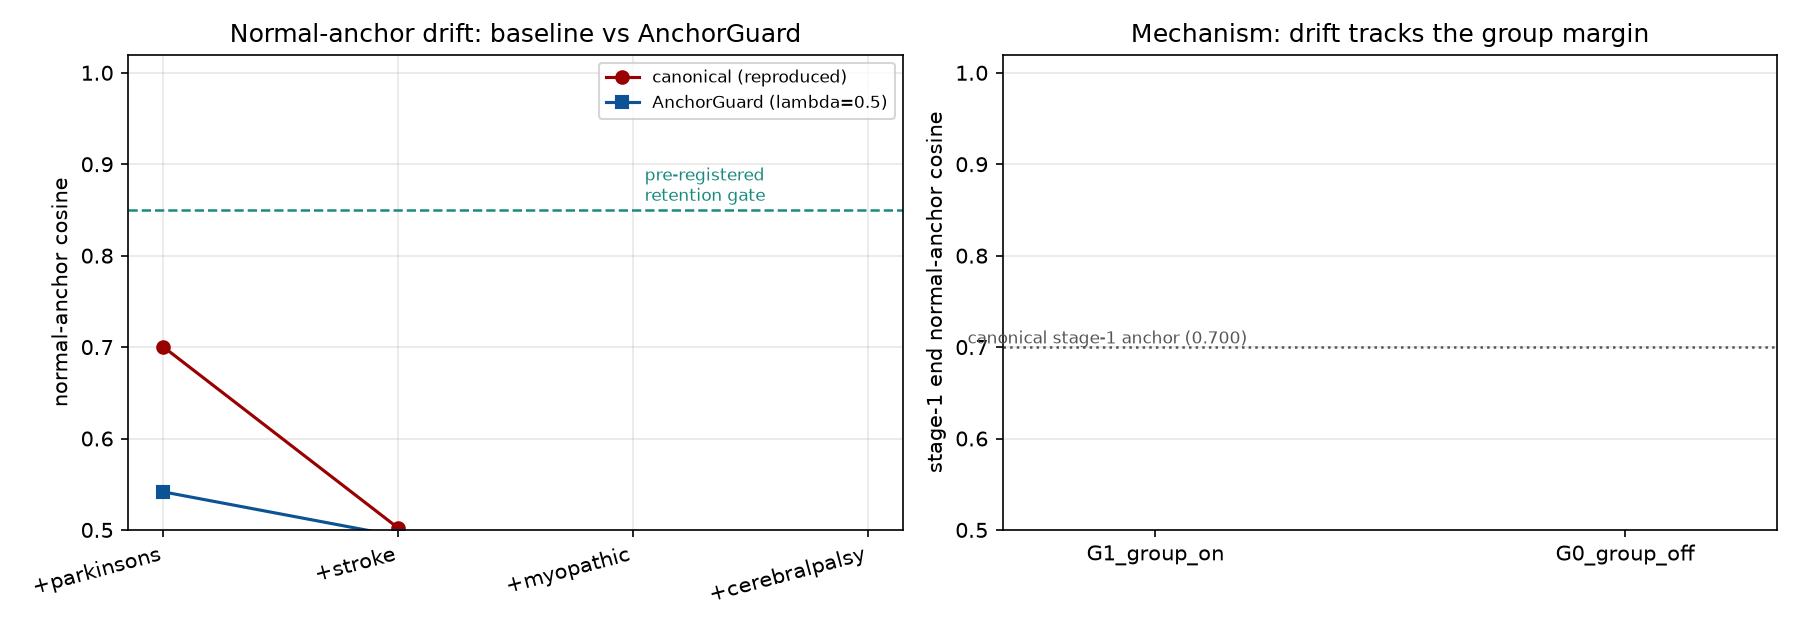

In [18]:
from IPython.display import Image, display

display(Image(filename="work/artifacts/real/anchor_guard_summary.png", width=800))

## What to read next

* `07_temporal_readout_diagnostic.ipynb` — readout-vs-representation diagnostic (backup paper).
* `09_predictive_surprise_world_model.ipynb` — frozen world-model probe with predictive surprise.
* `docs/neurips-brain-body.md` — the full roadmap, claim discipline, and 72-hour plan.

**Research use only.** No diagnostic or clinical claims are made or implied.
